<a href="https://colab.research.google.com/github/AlanChi0720/bio_ai/blob/main/pytorch_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3 Prerequisite: PyTorch Primer

**Why this notebook:** Phase 3 (both Track B and Track C) uses PyTorch instead of just sklearn. Before diving in, get comfortable with three things:
1. **Tensors** — PyTorch's array type, like NumPy arrays but with GPU support and autograd
2. **Autograd** — automatic differentiation; this is what makes neural network training work
3. **Training loop** — the pattern `forward → loss → backward → step` you'll use in every Phase 3 notebook

**Estimated time:** ~2 hours

We'll build a small MLP (multilayer perceptron) on the same GSE2034 breast cancer expression data you used in Phase 1, and beat (or match) the random forest baseline.

In [1]:
!pip install -q GEOparse

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## 1. Tensors

A tensor is a multi-dimensional array. If you know NumPy, you already know 90% of this.

In [3]:
# Create tensors
x = torch.tensor([(1.0, 2.0, 3.0), (1.0, 2.0, 3.0)])
print('x:', x, 'shape:', x.shape, 'dtype:', x.dtype)

# From NumPy
arr = np.array([[1, 2], [3, 4]], dtype=np.float32)
t = torch.from_numpy(arr)
print('t:', t, 'shape:', t.shape, 'dtype:', t.dtype)

# Math like NumPy
print('sum:', t.sum().item())
print('mean per column:', t.mean(dim=0))

# Move to GPU (if available)
t_gpu = t.to(device)
print('on device:', t_gpu.device)

x: tensor([[1., 2., 3.],
        [1., 2., 3.]]) shape: torch.Size([2, 3]) dtype: torch.float32
t: tensor([[1., 2.],
        [3., 4.]]) shape: torch.Size([2, 2]) dtype: torch.float32
sum: 10.0
mean per column: tensor([2., 3.])
on device: cuda:0


## 2. Autograd — The Magic Behind Neural Networks

When you set `requires_grad=True`, PyTorch tracks every operation on that tensor. Calling `.backward()` then computes derivatives automatically. This is how gradient descent works under the hood.

In [4]:
# Toy example: minimize f(w) = (w - 3)^2
# True minimum is at w = 3

w = torch.tensor([0.0], requires_grad=True)
lr = 0.1

for step in range(30):
    loss = (w - 3) ** 2          # forward: compute the function
    loss.backward()               # autograd: compute dL/dw
    with torch.no_grad():
        w -= lr * w.grad          # gradient step
    w.grad.zero_()                # reset gradient for next iteration
    if step % 2 == 0:
        print(f'step {step:2d}: w = {w.item():.4f}, loss = {loss.item():.4f}')

# Q: After 20 steps, w should be close to 3. This is exactly what happens during NN training,
# but with millions of parameters instead of one.

step  0: w = 0.6000, loss = 9.0000
step  2: w = 1.4640, loss = 3.6864
step  4: w = 2.0170, loss = 1.5099
step  6: w = 2.3709, loss = 0.6185
step  8: w = 2.5973, loss = 0.2533
step 10: w = 2.7423, loss = 0.1038
step 12: w = 2.8351, loss = 0.0425
step 14: w = 2.8944, loss = 0.0174
step 16: w = 2.9324, loss = 0.0071
step 18: w = 2.9568, loss = 0.0029
step 20: w = 2.9723, loss = 0.0012
step 22: w = 2.9823, loss = 0.0005
step 24: w = 2.9887, loss = 0.0002
step 26: w = 2.9927, loss = 0.0001
step 28: w = 2.9954, loss = 0.0000


## 3. Load Data — Reuse GSE2034 Breast Cancer (Tabular)

Same dataset as Phase 1: ~286 samples × ~22k genes, label = bone relapse (0/1). We'll treat it as a tabular classification problem.

In [5]:
import GEOparse
gse = GEOparse.get_GEO('GSE2034', destdir='./data', silent=True)

expr_frames, labels, sample_ids = [], [], []
for gsm_name, gsm in gse.gsms.items():
    table = gsm.table.set_index('ID_REF')['VALUE'].astype(float)
    expr_frames.append(table)
    chars = gsm.metadata.get('characteristics_ch1', [''])[0]
    labels.append(int(chars.split(': ')[-1]))
    sample_ids.append(gsm_name)

expr = pd.DataFrame(expr_frames, index=sample_ids).T  # genes x samples
X = expr.T.fillna(0).values.astype(np.float32)        # samples x genes
y = np.array(labels, dtype=np.int64)
print(f'X: {X.shape}, y: {y.shape}, positives: {y.sum()}/{len(y)}')

X: (286, 22283), y: (286,), positives: 69/286


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# Convert to PyTorch tensors
X_train_t = torch.from_numpy(X_train).to(device)
y_train_t = torch.from_numpy(y_train).to(device)
X_test_t  = torch.from_numpy(X_test).to(device)
y_test_t  = torch.from_numpy(y_test).to(device)
print('Tensors ready on', device)

Tensors ready on cuda


## 4. Define a Model

An MLP (multilayer perceptron) is the simplest neural network: a stack of linear layers with non-linearities (ReLU) between them. The architecture below has:
- Input: ~22k genes
- Hidden layer 1: 128 units
- Hidden layer 2: 32 units
- Output: 2 logits (one per class)
- Dropout for regularization (randomly zeros some activations during training)

In [7]:
class MLP(nn.Module):
    def __init__(self, n_features, n_classes=2, hidden=(128, 32), dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden[0])
        self.fc2 = nn.Linear(hidden[0], hidden[1])
        self.fc3 = nn.Linear(hidden[1], n_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)  # raw logits — CrossEntropyLoss applies softmax internally

model = MLP(n_features=X_train.shape[1]).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {n_params:,}')

MLP(
  (fc1): Linear(in_features=22283, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
Total parameters: 2,856,546


## 5. The Training Loop — The Most Important Pattern in Deep Learning

Every PyTorch training loop has the same shape:

```
for each epoch:
    model.train()                # turn ON dropout/batchnorm training behavior
    for each batch:
        optimizer.zero_grad()    # clear gradients from previous step
        logits = model(x)        # forward pass
        loss = loss_fn(logits, y) # compute loss
        loss.backward()          # backward pass — compute gradients
        optimizer.step()         # update weights
    
    model.eval()                 # turn OFF dropout for evaluation
    with torch.no_grad():        # don't track gradients (saves memory)
        evaluate on validation set
```

Memorize this. You'll write it in every Phase 3 notebook.

In [8]:
from sklearn.metrics import roc_auc_score

model = MLP(n_features=X_train.shape[1]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 20
history = {'train_loss': [], 'test_loss': [], 'test_auc': []}

for epoch in range(n_epochs):
    # --- TRAIN ---
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    # --- EVAL ---
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_t)
        test_loss = loss_fn(test_logits, y_test_t).item()
        probs = F.softmax(test_logits, dim=1)[:, 1].cpu().numpy()
        auc = roc_auc_score(y_test_t.cpu().numpy(), probs)

    history['train_loss'].append(loss.item())
    history['test_loss'].append(test_loss)
    history['test_auc'].append(auc)

    if epoch % 10 == 0 or epoch == n_epochs - 1:
        print(f'epoch {epoch:3d}: train_loss={loss.item():.4f}  test_loss={test_loss:.4f}  test_AUC={auc:.3f}')

epoch   0: train_loss=0.7350  test_loss=0.7174  test_AUC=0.617
epoch  10: train_loss=0.2276  test_loss=0.8354  test_AUC=0.719
epoch  19: train_loss=0.0932  test_loss=0.8947  test_AUC=0.751


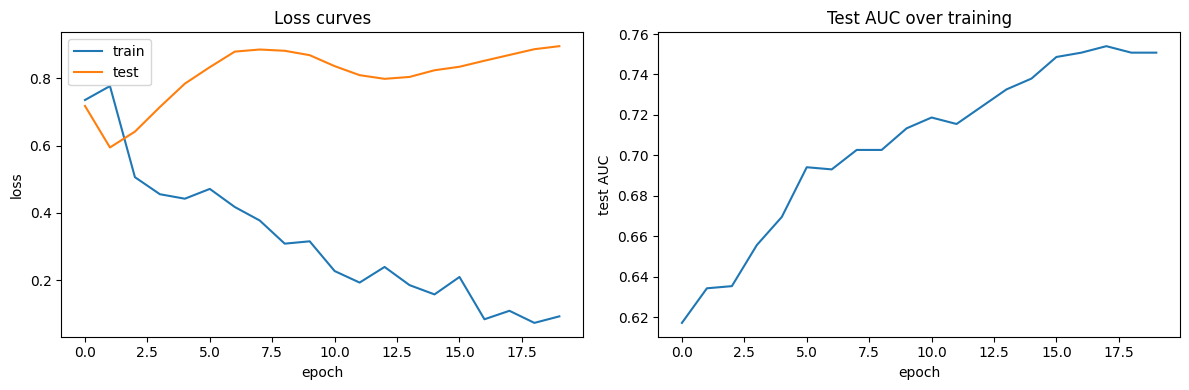

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='train')
ax1.plot(history['test_loss'], label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss curves')
ax2.plot(history['test_auc'])
ax2.set_xlabel('epoch'); ax2.set_ylabel('test AUC'); ax2.set_title('Test AUC over training')
plt.tight_layout(); plt.show()

# Q: Does the train loss go down while test loss goes up? That's overfitting.
# This dataset is very small (~200 train samples) so dropout + weight decay matter a lot.

## 6. Compare to Phase 1 Random Forest

On a small tabular dataset like GSE2034, a tree ensemble usually competes well with a neural net. The point of this notebook isn't to win — it's to learn the PyTorch idiom.

In [10]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f'MLP best test AUC: {max(history["test_auc"]):.3f}')
print(f'RF  test AUC:      {rf_auc:.3f}')

# Q: Which won? On small bio datasets RF often wins. Neural nets shine when
# (a) you have lots of data, OR (b) the input has structure (sequences, graphs, images).

MLP best test AUC: 0.754
RF  test AUC:      0.629


## 7. Mini-Exercise: Tweak the Architecture

Try one of these and see what happens:
1. Change `hidden=(128, 32)` to `(256, 64, 16)` — does deeper help on this dataset?
2. Set `dropout=0.0` — does it overfit faster?
3. Change `lr=1e-3` to `1e-2` or `1e-4` — what does the loss curve look like?
4. Add `nn.BatchNorm1d` between linear layers

**You're now ready for Phase 3.** Track B uses ESM-2 (a transformer). Track C uses GNNs (graph neural networks). Both follow the same training-loop pattern as above — just swap the model and the data.

## Reflection

1. Can you write the training loop pattern from memory: forward → loss → backward → step?
2. What does `model.train()` vs `model.eval()` actually change? (Hint: dropout, batchnorm)
3. Why do we use `with torch.no_grad():` during evaluation?
4. On 200 samples and 22k features, why might a random forest beat a neural net?

# PyTorch Basics 複習筆記
> Phase 3 前置：用 GSE2034 乳癌資料集建 MLP，學習 PyTorch 核心概念

---

## 1. Tensor 基礎

- Tensor = 多維陣列，概念上與 NumPy array 相同，但支援 GPU 和自動微分
- 常用操作：

```python
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
x.shape       # 形狀
x.dtype       # 資料型別（通常是 float32）
x.to(device)  # 移到 GPU

# 與 NumPy 互轉
t = torch.from_numpy(arr)
arr = t.numpy()
```

---

## 2. Autograd（自動微分）

**核心概念：** PyTorch 在你做運算時偷偷記錄操作路徑，`.backward()` 倒回去算每個參數的斜率（梯度）。

```python
w = torch.tensor([0.0], requires_grad=True)  # 開始錄影
loss = (w - 3) ** 2                           # 前向計算
loss.backward()                               # 自動算 d(loss)/dw
print(w.grad)                                 # 梯度值
```

**關鍵數學（以 y = x² 為例）：**
- dy/dx = 2x（x 每變動一點，y 變動多少）
- 梯度下降 = 沿斜率反方向走 → loss 下降

**梯度下降一步：**
```python
w -= lr * w.grad   # lr = 學習率，控制步伐大小
w.grad.zero_()     # 必須清掉！不然下次會累加
```

---

## 3. MLP 架構（本例）

```
22,000 個基因（輸入）
    ↓ Linear + ReLU + Dropout
  128 個 units
    ↓ Linear + ReLU + Dropout
   32 個 units
    ↓ Linear
    2 個 logits（復發 / 不復發）
```

| 元件 | 功能 |
|------|------|
| `nn.Linear` | 加權求和（每個 unit 看所有輸入） |
| `ReLU` | 負值變 0，加入非線性，讓模型學複雜模式 |
| `Dropout(0.5)` | 訓練時隨機關掉 50% unit，防止過擬合 |
| `CrossEntropyLoss` | 分類任務的 loss，內建 softmax |

```python
class MLP(nn.Module):
    def __init__(self, n_features, n_classes=2, hidden=(128, 32), dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden[0])
        self.fc2 = nn.Linear(hidden[0], hidden[1])
        self.fc3 = nn.Linear(hidden[1], n_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)  # raw logits
```

---

## 4. Training Loop（最重要的 Pattern）

```python
for epoch in range(n_epochs):
    # --- 訓練 ---
    model.train()              # 開啟 dropout/batchnorm 訓練模式
    optimizer.zero_grad()      # 清掉上次梯度（必須！）
    logits = model(X)          # forward：算預測值
    loss = loss_fn(logits, y)  # 算 loss
    loss.backward()            # backward：算每個參數的梯度
    optimizer.step()           # 更新參數

    # --- 評估 ---
    model.eval()               # 關閉 dropout（全力輸出）
    with torch.no_grad():      # 不追蹤梯度（省記憶體）
        test_logits = model(X_test)
        ...
```

### 四步核心順序（不能亂）：
1. `zero_grad()` → 清梯度
2. `model(x)` → 前向傳播
3. `loss.backward()` → 反向傳播
4. `optimizer.step()` → 更新權重

---

## 5. 常見問題解答

**`model.train()` vs `model.eval()` 差在哪？**

| | `model.train()` | `model.eval()` |
|---|---|---|
| Dropout | 隨機關掉 unit | 全部打開 |
| BatchNorm | 用當前 batch 統計 | 用訓練時記下的統計 |

> 不是「開始/結束訓練」的開關，而是切換**行為模式**。

---

**為什麼評估時要 `with torch.no_grad():`？**

評估時只需要看預測結果，不需要計算梯度。關掉 tracking 可以省記憶體、加快速度。

---

**Overfitting 怎麼看？**

Loss curve 出現「剪刀形」：
- Train loss 持續下降 → 趨近 0
- Test loss 先降後**持續上升**

本例（200 樣本 vs 22k 基因）：參數遠多於樣本，天生容易 overfit。

---

**為什麼 Random Forest 可能贏過 Neural Net？**

Neural nets 在以下條件才佔優：
- 資料量大（萬筆以上）
- 輸入有結構（序列、圖、影像）

小樣本 + 高維度（tabular）→ Random Forest 更穩。

---

## 6. 關鍵超參數

| 參數 | 本例設定 | 影響 |
|------|---------|------|
| `lr` (學習率) | 1e-3 | 太大震盪，太小收斂慢 |
| `dropout` | 0.5 | 越大越保守，防止 overfit |
| `weight_decay` | 1e-4 | L2 正則化，也防 overfit |
| `hidden` | (128, 32) | 層數越多越有表達力，但也越容易 overfit |

---

## 7. Phase 3 銜接提醒

- Track B（ESM-2）和 Track C（GNN）都使用**相同的 training loop pattern**
- 差別只在：換模型 + 換資料
- 這個 loop 是 PyTorch 的核心 idiom，之後每個 notebook 都會用到
